In [1]:
from astropy import units as u
from astropy.coordinates import SkyCoord

import matplotlib.pyplot as plt

from gammapy.catalog import SourceCatalog4FGL
from fermipy.gtanalysis import GTAnalysis
from fermipy.plotting import ROIPlotter
import numpy as np
catalog_4fgl = SourceCatalog4FGL("/Users/vdk/shared/fermibottle/gll_psc_v35.fit")

# Info about our initial catalogue source

In [2]:
catalog_4fgl['4FGL J1908.6+0915e']

/Users/vdk/miniforge3/envs/fermipy/lib/python3.9/site-packages/gammapy/catalog/fermi.py:218: FutureWarning: Format strings passed to MaskedConstant are ignored, but in future may error or produce different behavior
  ss += "{:<16s} : {:.3f}\n".format("ASSOC_PROB_BAY", d["ASSOC_PROB_BAY"])
/Users/vdk/miniforge3/envs/fermipy/lib/python3.9/site-packages/gammapy/catalog/fermi.py:219: FutureWarning: Format strings passed to MaskedConstant are ignored, but in future may error or produce different behavior
  ss += "{:<16s} : {:.3f}\n".format("ASSOC_PROB_LR", d["ASSOC_PROB_LR"])


# Load config and setup of the analysis

In [3]:
gta = GTAnalysis('/Users/vdk/software/my_codebase/python/data_analysis/fermi_lat/sgr1900/fermi_config_sgr1900_15deg_two_sources_GAL.yaml', logging={'verbosity': 3})

2025-05-14 17:28:40 INFO    GTAnalysis.__init__(): 
--------------------------------------------------------------------------------
fermipy version 1.3.1 
ScienceTools version 2.2.0


In [19]:
gta.setup()

2025-05-14 17:59:00 INFO    GTAnalysis.setup(): Running setup.
2025-05-14 17:59:00 INFO    GTBinnedAnalysis.setup(): Running setup for component 00
2025-05-14 17:59:00 INFO    GTBinnedAnalysis._select_data(): Skipping data selection.
2025-05-14 17:59:00 INFO    GTBinnedAnalysis._create_ltcube(): Skipping LT Cube.
2025-05-14 17:59:01 INFO    GTBinnedAnalysis._create_expcube(): Skipping gtexpcube.
Set MJD-OBS to 54682.655283 from DATE-OBS.
Set MJD-END to 60774.984781 from DATE-END'. [astropy.wcs.wcs]
2025-05-14 17:59:01 INFO    GTBinnedAnalysis._create_srcmaps(): Skipping gtsrcmaps.
2025-05-14 17:59:01 INFO    GTBinnedAnalysis.setup(): Finished setup for component 00
2025-05-14 17:59:01 INFO    GTBinnedAnalysis._create_binned_analysis(): Creating BinnedAnalysis for component 00.
2025-05-14 17:59:06 INFO    GTAnalysis.setup(): Initializing source properties
2025-05-14 17:59:06 INFO    GTAnalysis.setup(): Finished setup.


# Print of the model to check what we have. The first source is the central source in the field of view. The one that we try to divide

In [20]:
gta.print_model()

2025-05-14 17:59:06 INFO    GTAnalysis.print_model(): 
sourcename            offset    norm  eflux     index        ts       npred free
--------------------------------------------------------------------------------
Src2_pointlike         0.128   2.999  1.86e-06   2.00       nan       196.7    *
Src1_pointlike         0.334   4.856  3.02e-06   2.00       nan       318.5    *
4FGL J1910.2+0904c     0.430   0.440  1.07e-05   2.44       nan      2275.0    *
4FGL J1911.0+0905      0.619   0.691  5.43e-05   2.19       nan     10385.6    *
4FGL J1911.8+0903c     0.808   0.535  5.61e-06   2.34       nan      1047.1    *
4FGL J1912.0+0927      0.869   0.335  3.95e-06   2.77       nan      1201.7    *
4FGL J1908.7+0812      1.056   1.751  6.79e-06   3.21       nan      2381.5    *
4FGL J1913.3+0905      1.183   0.783  6.31e-06   3.29       nan      1818.0    *
4FGL J1912.7+0957      1.226   0.486   4.9e-06   2.80       nan      1504.6    *
4FGL J1911.7+1014c     1.241   0.340  3.28e-06   3.01 

# Check the ROI

2025-05-14 17:59:06 INFO    GTBinnedAnalysis.write_xml(): Writing /Users/vdk/software/my_codebase/python/data_analysis/fermi_lat/sgr1900/output_sgr_1GeV_15deg_two_sources_GAL/initial_00.xml...
2025-05-14 17:59:06 INFO    GTAnalysis.write_fits(): Writing /Users/vdk/software/my_codebase/python/data_analysis/fermi_lat/sgr1900/output_sgr_1GeV_15deg_two_sources_GAL/initial.fits...
2025-05-14 17:59:09 INFO    GTBinnedAnalysis.write_model_map(): Generating model map for component 00.
2025-05-14 17:59:10 INFO    GTAnalysis.write_roi(): Writing /Users/vdk/software/my_codebase/python/data_analysis/fermi_lat/sgr1900/output_sgr_1GeV_15deg_two_sources_GAL/initial.npy...


<Figure size 2000x2000 with 0 Axes>

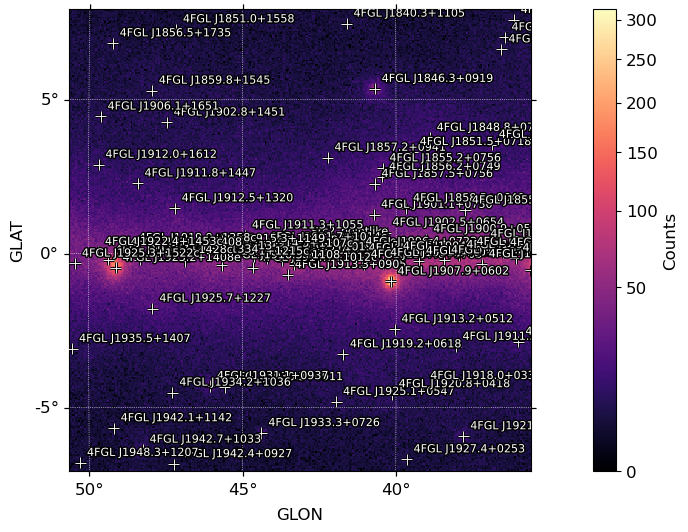

In [21]:
plt.figure(figsize=(20, 20))
gta.write_roi('initial',make_plots=True,save_model_map=True)
plt.show()

# Free parameters of the sources in the region 3 degrees around the source

**Why We Free Parameters Within 3° Radius Around the Source**

During the fitting procedure, we free the spectral parameters of sources within a 3° radius around our target source. This allows the optimizer to account for potential spectral and spatial confusion between nearby sources, improving the accuracy of the fit.

Sources located further than 3° are kept fixed, as their contribution to the model within the region of interest is minimal due to the instrument’s point spread function (PSF) and the limited angular resolution at higher energies. Keeping distant sources fixed also stabilizes the fit and reduces the number of free parameters, ensuring better convergence and computational efficiency. 

In [22]:
gta.free_sources(free=False)
gta.free_sources(skydir=gta.roi[gta.roi.sources[0].name].skydir,distance=[3.0],free=True)

2025-05-14 17:59:13 INFO    GTAnalysis.free_source(): Fixing parameters for Src2_pointlike        : ['Prefactor']
2025-05-14 17:59:13 INFO    GTAnalysis.free_source(): Fixing parameters for Src1_pointlike        : ['Prefactor']
2025-05-14 17:59:13 INFO    GTAnalysis.free_source(): Fixing parameters for 4FGL J1910.2+0904c    : ['Prefactor']
2025-05-14 17:59:13 INFO    GTAnalysis.free_source(): Fixing parameters for 4FGL J1911.0+0905     : ['norm']
2025-05-14 17:59:13 INFO    GTAnalysis.free_source(): Fixing parameters for 4FGL J1911.8+0903c    : ['Prefactor']
2025-05-14 17:59:13 INFO    GTAnalysis.free_source(): Fixing parameters for 4FGL J1912.0+0927     : ['norm']
2025-05-14 17:59:13 INFO    GTAnalysis.free_source(): Fixing parameters for 4FGL J1908.7+0812     : ['norm']
2025-05-14 17:59:13 INFO    GTAnalysis.free_source(): Fixing parameters for 4FGL J1913.3+0905     : ['Prefactor']
2025-05-14 17:59:13 INFO    GTAnalysis.free_source(): Fixing parameters for 4FGL J1912.7+0957     : ['n

In [23]:
gta.fit()

2025-05-14 17:59:14 INFO    GTAnalysis.fit(): Starting fit.
/Users/vdk/miniforge3/envs/fermipy/lib/python3.9/site-packages/scipy/interpolate/_fitpack2.py:313: UserWarning: 
The maximal number of iterations maxit (set to 20 by the program)
allowed for finding a smoothing spline with fp=s has been reached: s
too small.
There is an approximation returned but the corresponding weighted sum
of squared residuals does not satisfy the condition abs(fp-s)/s < tol.
  warnings.warn(message)
2025-05-14 18:02:41 INFO    GTAnalysis.fit(): Fit returned successfully. Quality:   3 Status:   0
2025-05-14 18:02:41 INFO    GTAnalysis.fit(): LogLike:   212704.636 DeltaLogLike:        7.187 


{'fit_quality': 3,
 'fit_status': 0,
 'fit_success': True,
 'dloglike': 7.187340087955818,
 'edm': 0.001171828044885133,
 'loglike': 212704.6362497555,
 'covariance': array([[ 2.72600103e-02,  3.74226293e-02,  1.37119658e-03, ...,
         -1.36340905e-05, -9.75828248e-06, -9.76851108e-05],
        [ 3.74226293e-02,  1.16167933e-01, -3.23803917e-02, ...,
         -1.37970503e-05, -1.49964775e-05, -1.20807370e-04],
        [ 1.37119658e-03, -3.23803917e-02,  4.21429526e-02, ...,
         -3.61662311e-06, -2.71251237e-06,  1.64688823e-05],
        ...,
        [-1.36340905e-05, -1.37970503e-05, -3.61662311e-06, ...,
          2.76605446e-06,  1.39817306e-06, -2.91896241e-05],
        [-9.75828248e-06, -1.49964775e-05, -2.71251237e-06, ...,
          1.39817306e-06,  2.92120849e-06,  2.71998977e-05],
        [-9.76851108e-05, -1.20807370e-04,  1.64688823e-05, ...,
         -2.91896241e-05,  2.71998977e-05,  2.05702221e-03]]),
 'correlation': array([[ 1.        ,  0.66500997,  0.04045519, 

In [24]:
plt.clf()
tsmap_postfit_no_source = gta.tsmap(
    prefix='TSmap_no_source',
    make_plots=True,
    write_fits=True,
    write_npy=True, 
    exclude=gta.roi.sources[0].name)

2025-05-14 18:02:41 INFO    GTAnalysis.tsmap(): Generating TS map
2025-05-14 18:02:44 INFO    GTAnalysis._make_tsmap_fast(): Fitting test source.
2025-05-14 18:03:42 INFO    GTAnalysis.tsmap(): Finished TS map
2025-05-14 18:03:45 WARNING GTAnalysis.tsmap(): Saving TS maps in .npy files is disabled b/c of incompatibilities in python3, remove the maps from the /Users/vdk/software/my_codebase/python/data_analysis/fermi_lat/sgr1900/output_sgr_1GeV_15deg_two_sources_GAL/TSmap_no_source_pointsource_powerlaw_2.00_tsmap.npy
2025-05-14 18:03:45 INFO    GTAnalysis.tsmap(): Execution time: 63.52 s


<Figure size 640x480 with 0 Axes>

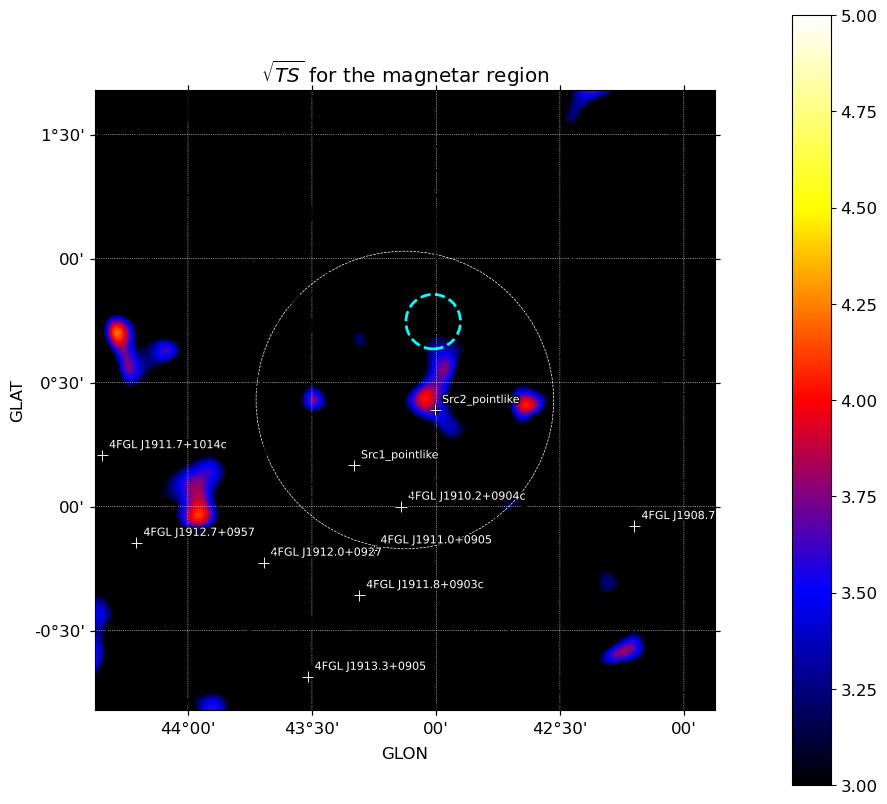

In [25]:
p = ROIPlotter(tsmap_postfit_no_source['sqrt_ts'], roi=gta.roi, 
               cmap='ds9_b',   # example colormap
               graticule_radii=[0.6],  # optional, for overlaying circles
               label_ts_threshold=5.0)  # optional threshold for labeling

snr_g_043 = SkyCoord(43.011, 0.746, unit="deg", frame="galactic")

plt.figure(figsize=(10, 10))  # e.g., 10x10 inches
p.plot(interpolation='bicubic', zoom=6,vmin=3,vmax=5, levels=[0,3,5])
p.draw_circle(0.11,  # radius in degrees
              skydir=snr_g_043,
              edgecolor='cyan',
              linewidth=2.0,
              linestyle='--')

plt.title("$\sqrt{TS}$ for the magnetar region")
plt.show()

Now we see with how much of TS we can detect each source. $\sqrt{TS} = \sigma$ of detection. Need to have $>5 \sigma$ in order to be able to say that source is detected

In [26]:
gta.print_model()

2025-05-14 18:03:45 INFO    GTAnalysis.print_model(): 
sourcename            offset    norm  eflux     index        ts       npred free
--------------------------------------------------------------------------------
Src2_pointlike         0.128  17.608  1.95e-06   2.90     22.61       598.7    *
Src1_pointlike         0.334  12.251  2.92e-06   2.38     31.69       577.4    *
4FGL J1910.2+0904c     0.430   0.409     1e-05   2.33    227.66      1858.5    *
4FGL J1911.0+0905      0.619   0.697  5.45e-05   2.19   6463.94     10452.8    *
4FGL J1911.8+0903c     0.808   0.533  5.59e-06   2.34     69.65      1046.4    *
4FGL J1912.0+0927      0.869   0.329  3.85e-06   2.74     82.11      1157.1    *
4FGL J1908.7+0812      1.056   1.736  6.72e-06   3.20    237.29      2352.1    *
4FGL J1913.3+0905      1.183   0.785  6.33e-06   3.29    322.73      1827.6    *
4FGL J1912.7+0957      1.226   0.486  4.91e-06   2.80    149.77      1506.4    *
4FGL J1911.7+1014c     1.241   0.336  3.25e-06   2.99 

In [10]:
plt.clf()
tsmap_postfit = gta.tsmap(prefix='TSmap_start',make_plots=True,write_fits=True,write_npy=True)

2025-05-14 17:32:13 INFO    GTAnalysis.tsmap(): Generating TS map
2025-05-14 17:32:16 INFO    GTAnalysis._make_tsmap_fast(): Fitting test source.
2025-05-14 17:33:12 INFO    GTAnalysis.tsmap(): Finished TS map
2025-05-14 17:33:15 WARNING GTAnalysis.tsmap(): Saving TS maps in .npy files is disabled b/c of incompatibilities in python3, remove the maps from the /Users/vdk/software/my_codebase/python/data_analysis/fermi_lat/sgr1900/output_sgr_1GeV_15deg_two_sources_GAL/TSmap_start_pointsource_powerlaw_2.00_tsmap.npy
2025-05-14 17:33:15 INFO    GTAnalysis.tsmap(): Execution time: 61.53 s


<Figure size 640x480 with 0 Axes>

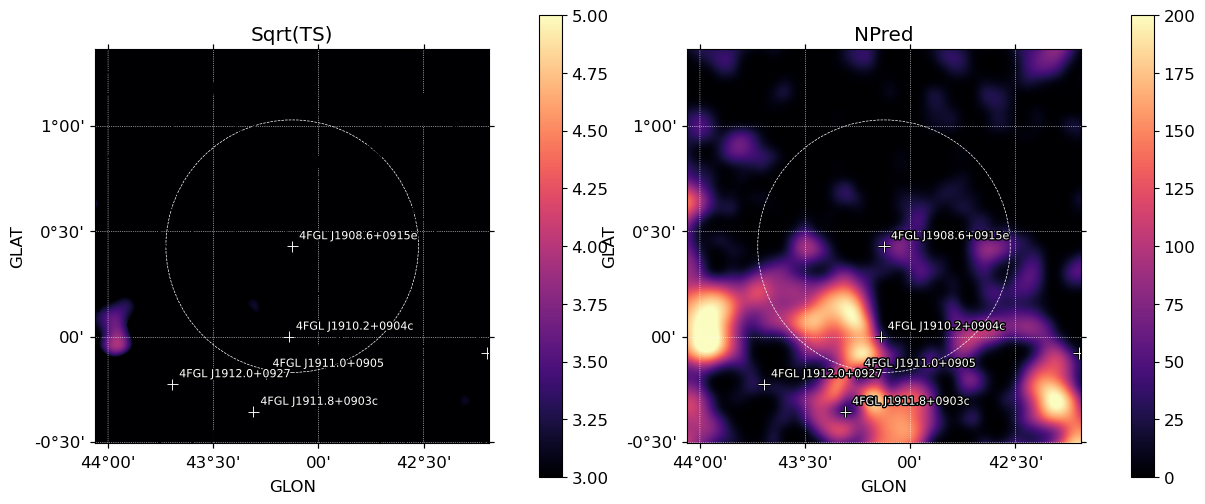

In [11]:
plt.clf()
fig = plt.figure(figsize=(14,6))
ROIPlotter(
    tsmap_postfit['sqrt_ts'],
    roi=gta.roi, 
    graticule_radii=[0.6]).plot(
        interpolation='bicubic',
        levels=[0,3,5],
        vmin=3,
        vmax=5,
        subplot=121,
        cmap='magma', 
        zoom = 8
    )
plt.gca().set_title('Sqrt(TS)')
ROIPlotter(
    tsmap_postfit['npred'],
    roi=gta.roi, 
    graticule_radii=[0.6]).plot(
        interpolation='bicubic',
        vmin=0,
        vmax=200,
        subplot=122,
        cmap='magma', 
        zoom = 8
    )
plt.gca().set_title('NPred')
plt.show()

# Removal of the main source, and division of the region for two parts

## Two point like sources

In [12]:
glon1, glat1 = 43.33, 0.1667  # Bottom red circle
glon2, glat2 = 43.08,  0.43  # Central blob

c1 = SkyCoord(l=glon1*u.deg, b=glat1*u.deg, frame='galactic')
c2 = SkyCoord(l=glon2*u.deg, b=glat2*u.deg, frame='galactic')

ra1, dec1 = c1.icrs.ra.deg, c1.icrs.dec.deg
ra2, dec2 = c2.icrs.ra.deg, c2.icrs.dec.deg
dec2 = 9.1333

gta.delete_source('4FGL J1908.6+0915e') 
gta.delete_source('Src1_pointlike')  
gta.delete_source('Src2_pointlike')  

2025-05-14 17:33:19 INFO    GTAnalysis.delete_source(): Deleting source 4FGL J1908.6+0915e
2025-05-14 17:33:19 ERROR   GTAnalysis.delete_source(): No source with name: Src1_pointlike
2025-05-14 17:33:19 ERROR   GTAnalysis.delete_source(): No source with name: Src2_pointlike


In [ ]:
for i, (ra, dec) in enumerate([(ra1,dec1), (ra2,dec2)], start=1):
    gta.add_source(f"Src{i}_pointlike", {
        'type':         'PointSource',
        'ra':          ra,       # if your coordsys is celestial, use 'ra':…,'dec':…
        'dec':          dec,
        'spectrum_type':'PowerLaw',
        'Index':        2.0,
        'Prefactor':    1e-13,
        'Scale':        1000.0
    })

2025-05-14 17:33:58 INFO    GTAnalysis.add_source(): Adding source Src1_pointlike
2025-05-14 17:33:59 INFO    GTAnalysis.add_source(): Adding source Src2_pointlike


In [17]:
gta.optimize()
gta.fit()

2025-05-14 17:34:23 INFO    GTAnalysis.optimize(): Starting


Joint fit  ['galdiff', '4FGL J1907.9+0602', '4FGL J1923.2+1408e', '4FGL J1911.0+0905', '4FGL J1906.4+0723']


/Users/vdk/miniforge3/envs/fermipy/lib/python3.9/site-packages/scipy/interpolate/_fitpack2.py:313: UserWarning: 
The maximal number of iterations maxit (set to 20 by the program)
allowed for finding a smoothing spline with fp=s has been reached: s
too small.
There is an approximation returned but the corresponding weighted sum
of squared residuals does not satisfy the condition abs(fp-s)/s < tol.
  warnings.warn(message)


Fitting shape galdiff TS: 3894939.164
Fitting shape 4FGL J1907.9+0602 TS:  26597.247
Fitting shape 4FGL J1923.2+1408e TS:  21141.943
Fitting shape 4FGL J1911.0+0905 TS:   6737.309
Fitting shape 4FGL J1846.3+0919 TS:   5498.880
Fitting shape 4FGL J1931.1+0937 TS:   3204.214
Fitting shape 4FGL J1942.7+1033 TS:   2875.171
Fitting shape 4FGL J1906.4+0723 TS:   1966.506
Fitting shape 4FGL J1857.7+0246e TS:   1245.047
Fitting shape 4FGL J1933.3+0726 TS:    952.868
Fitting shape 4FGL J1906.9+0712 TS:    625.468
Fitting shape 4FGL J1921.4+0136 TS:    485.374
Fitting shape 4FGL J1858.0+0354 TS:    380.049
Fitting shape 4FGL J1858.3+0209 TS:    375.230
Fitting shape 4FGL J1913.3+0905 TS:    319.766
Fitting shape 4FGL J1910.2+0904c TS:    296.674
Fitting shape 4FGL J1900.4+0339 TS:    278.071
Fitting shape 4FGL J1908.7+0812 TS:    251.735
Fitting shape 4FGL J1922.7+1428c TS:    191.126
Fitting shape 4FGL J1902.2+0448 TS:    181.630
Fitting shape 4FGL J1901.1+0730 TS:    173.672
Fitting shape 4FGL

2025-05-14 17:42:52 INFO    GTAnalysis.optimize(): Finished
2025-05-14 17:42:52 INFO    GTAnalysis.optimize(): LogLike: 212697.128774 Delta-LogLike: 373.150965
2025-05-14 17:42:52 INFO    GTAnalysis.optimize(): Execution time: 509.58 s
2025-05-14 17:42:52 INFO    GTAnalysis.fit(): Starting fit.
2025-05-14 17:45:44 INFO    GTAnalysis.fit(): Fit returned successfully. Quality:   3 Status:   0
2025-05-14 17:45:44 INFO    GTAnalysis.fit(): LogLike:   212697.697 DeltaLogLike:        0.568 


{'fit_quality': 3,
 'fit_status': 0,
 'fit_success': True,
 'dloglike': 0.5682645698543638,
 'edm': 0.001148834160970902,
 'loglike': 212697.69703811337,
 'covariance': array([[ 2.68437528e-02,  3.71744644e-02,  1.43999347e-03, ...,
         -1.37665627e-05, -9.74500100e-06, -9.47169046e-05],
        [ 3.71744644e-02,  1.16385123e-01, -3.24684442e-02, ...,
         -1.40684792e-05, -1.50810077e-05, -1.18874723e-04],
        [ 1.43999347e-03, -3.24684442e-02,  4.23617559e-02, ...,
         -3.70794636e-06, -2.75550845e-06,  1.66340744e-05],
        ...,
        [-1.37665627e-05, -1.40684792e-05, -3.70794636e-06, ...,
          2.73788811e-06,  1.38478488e-06, -2.90080906e-05],
        [-9.74500100e-06, -1.50810077e-05, -2.75550845e-06, ...,
          1.38478488e-06,  2.91082072e-06,  2.72710257e-05],
        [-9.47169046e-05, -1.18874723e-04,  1.66340744e-05, ...,
         -2.90080906e-05,  2.72710257e-05,  2.05613993e-03]]),
 'correlation': array([[ 1.        ,  0.66508074,  0.04270237

In [18]:
gta.print_model()

2025-05-14 17:45:44 INFO    GTAnalysis.print_model(): 
sourcename            offset    norm  eflux     index        ts       npred free
--------------------------------------------------------------------------------
Src2_pointlike         0.128   2.999  1.86e-06   2.00     12.77       205.0    *
Src1_pointlike         0.334   4.856  3.02e-06   2.00     26.24       331.9    *
4FGL J1910.2+0904c     0.430   0.440  1.07e-05   2.44    280.43      2275.0    *
4FGL J1911.0+0905      0.619   0.691  5.43e-05   2.19   6353.81     10385.6    *
4FGL J1911.8+0903c     0.808   0.535  5.61e-06   2.34     69.97      1047.1    *
4FGL J1912.0+0927      0.869   0.335  3.95e-06   2.77     86.13      1201.7    *
4FGL J1908.7+0812      1.056   1.751  6.79e-06   3.21    241.74      2381.5    *
4FGL J1913.3+0905      1.183   0.783  6.31e-06   3.29    321.46      1818.0    *
4FGL J1912.7+0957      1.226   0.486   4.9e-06   2.80    149.49      1504.6    *
4FGL J1911.7+1014c     1.241   0.340  3.28e-06   3.01 

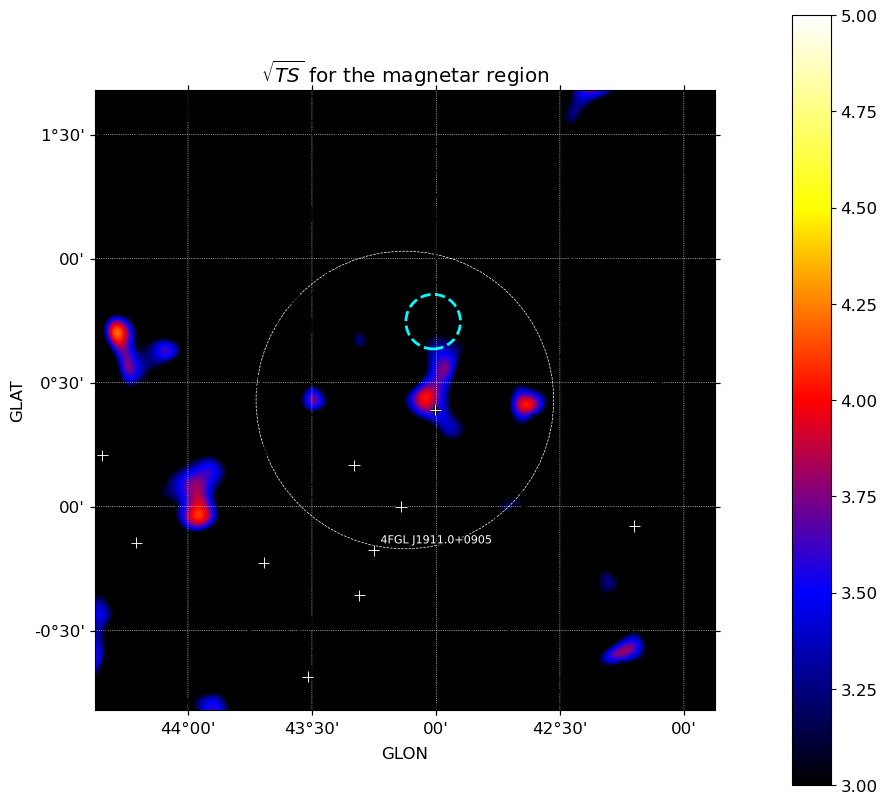

In [27]:
p = ROIPlotter(tsmap_postfit_no_source['sqrt_ts'], roi=gta.roi, 
               cmap='ds9_b',   # example colormap
               graticule_radii=[0.6],  # optional, for overlaying circles
               label_ts_threshold=1000.0)  # optional threshold for labeling

snr_g_043 = SkyCoord(43.011, 0.746, unit="deg", frame="galactic")

plt.figure(figsize=(10, 10))  # e.g., 10x10 inches
p.plot(interpolation='bicubic', zoom=6,vmin=3,vmax=5, levels=[0,3,5])
p.draw_circle(0.11,  # radius in degrees
              skydir=snr_g_043,
              edgecolor='cyan',
              linewidth=2.0,
              linestyle='--')

plt.title("$\sqrt{TS}$ for the magnetar region")
plt.show()

In [ ]:
glon1, glat1 = 43.33, 0.1667  # Bottom red circle
glon2, glat2 = 43.08,  0.43  # Central blob


gta.delete_source('4FGL J1908.6+0915e') 
gta.delete_source('Src1_pointlike')  
gta.delete_source('Src2_pointlike')


for i, (lon, lat) in enumerate([(glon1, glat1), (glon2, glat2)], start=1):
    gta.add_source(f"Src{i}_pointlike", {
        'type':         'PointSource',
        'ra':          lon,       # if your coordsys is celestial, use 'ra':…,'dec':…
        'dec':          lat,
        'spectrum_type':'PowerLaw',
        'Index':        2.0,
        'Prefactor':    1e-13,
        'Scale':        1000.0
    })